# Trader Performance vs Market Sentiment Analysis

## Objective
Analyze how Bitcoin market sentiment (Fear vs Greed) influences trader behavior and performance on Hyperliquid.

## Data Sources
- Bitcoin Fear-Greed Index
- Hyperliquid Historical Trader Execution Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')

## 1. Data Loading and Preparation

In [2]:
# Load Fear and Greed Index
fg = pd.read_csv('data/fear_greed_index.csv')
fg['timestamp'] = pd.to_datetime(fg['timestamp'], unit='s')
fg['date'] = fg['timestamp'].dt.date
fg = fg.sort_values('date')
print(f"Fear Greed Data: {fg.shape}")
print(fg.head())

Fear Greed Data: (2644, 4)
            timestamp  value classification        date
0 2018-02-01 05:30:00     30           Fear  2018-02-01
1 2018-02-02 05:30:00     15   Extreme Fear  2018-02-02
2 2018-02-03 05:30:00     40           Fear  2018-02-03
3 2018-02-04 05:30:00     24   Extreme Fear  2018-02-04
4 2018-02-05 05:30:00     11   Extreme Fear  2018-02-05


In [3]:
# Load Historical Execution Data
hd = pd.read_csv('data/historical_data.csv')
hd['Timestamp'] = pd.to_datetime(hd['Timestamp'], unit='ms')
hd['date'] = hd['Timestamp'].dt.date
print(f"Historical Data: {hd.shape}")
print(hd.head())

Historical Data: (211224, 17)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order

## 2. Metric Engineering

In [4]:
# Calculate Daily Trader Metrics

def calculate_daily_metrics(x):
    return pd.Series({
        'daily_pnl': x['Closed PnL'].sum(),
        'total_volume': x['Size USD'].sum(),
        'trade_count': len(x),
        'win_rate': (x['Closed PnL'] > 0).mean(),
        'avg_trade_size': x['Size USD'].mean(),
        'long_ratio': (x['Side'] == 'BUY').mean()
    })

daily_stats = hd.groupby(['Account', 'date']).apply(calculate_daily_metrics).reset_index()
print(f"Daily Stats: {daily_stats.shape}")
print(daily_stats.head())

Daily Stats: (102, 8)
                                      Account        date     daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -3.275059e+05   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  1.927736e+06   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  2.060745e+04   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  1.709873e+04   
4  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-06-15  1.017915e+04   

   total_volume  trade_count  win_rate  avg_trade_size  long_ratio  
0    6842632.02        462.0  0.025974    14810.891818    0.300866  
1   54854631.95       3356.0  0.405542    16345.241940    0.468415  
2     797679.97        320.0  0.531250     2492.749906    0.453125  
3    5982611.50       3533.0  0.435041     1693.351684    0.432494  
4    5255196.19       3427.0  0.442369     1533.468395    0.403268  


C:\Users\Windows\AppData\Local\Temp\ipykernel_18504\2607712766.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_stats = hd.groupby(['Account', 'date']).apply(calculate_daily_metrics).reset_index()


## 3. Merging Data

In [5]:
# Merge with Fear and Greed Index
merged_df = pd.merge(daily_stats, fg[['date', 'value', 'classification']], on='date', how='inner')
merged_df['sentiment_regime'] = merged_df['classification']
print(f"Merged Data: {merged_df.shape}")
print(merged_df.head())

Merged Data: (77, 11)
                                      Account        date     daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -3.275059e+05   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  1.927736e+06   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  2.060745e+04   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  1.709873e+04   
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03 -1.000000e+00   

   total_volume  trade_count  win_rate  avg_trade_size  long_ratio  value  \
0    6842632.02        462.0  0.025974    14810.891818    0.300866     74   
1   54854631.95       3356.0  0.405542    16345.241940    0.468415     44   
2     797679.97        320.0  0.531250     2492.749906    0.453125     74   
3    5982611.50       3533.0  0.435041     1693.351684    0.432494     44   
4      30351.00          5.0  0.000000     6070.200000    0.400000     50   

  classification sentiment_regime  
0          Greed            

## 4. Analysis Phase 1: Performance vs Sentiment

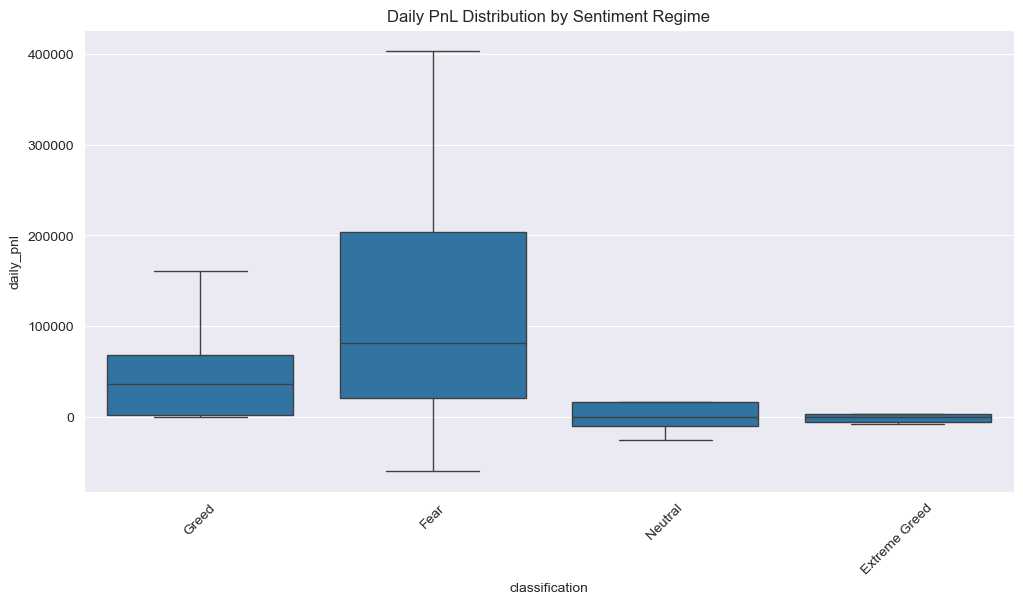

In [6]:
# PnL Distribution by Sentiment
plt.figure(figsize=(12, 6))
sns.boxplot(x='classification', y='daily_pnl', data=merged_df, showfliers=False)
plt.title('Daily PnL Distribution by Sentiment Regime')
plt.xticks(rotation=45)
plt.show()

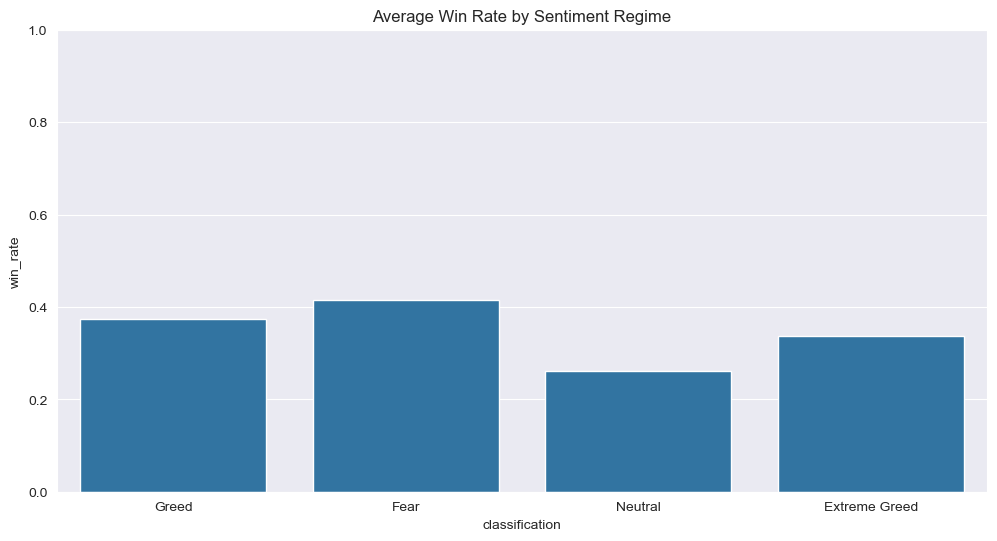

In [7]:
# Win Rate by Sentiment
plt.figure(figsize=(12, 6))
sns.barplot(x='classification', y='win_rate', data=merged_df, errorbar=None)
plt.title('Average Win Rate by Sentiment Regime')
plt.ylim(0, 1)
plt.show()

## 5. Analysis Phase 2: Behavioral Changes

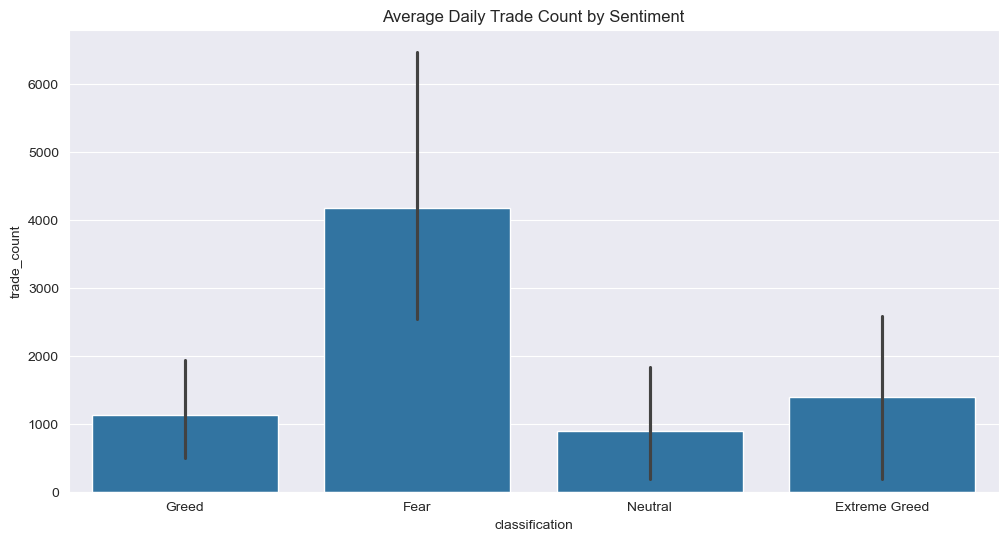

In [8]:
# Trade Frequency vs Sentiment
plt.figure(figsize=(12, 6))
sns.barplot(x='classification', y='trade_count', data=merged_df)
plt.title('Average Daily Trade Count by Sentiment')
plt.show()

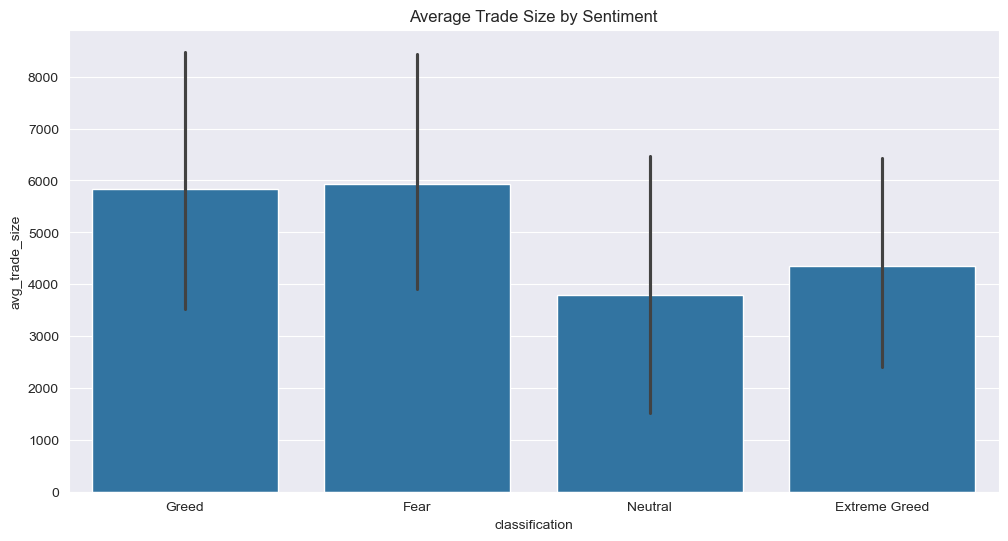

In [9]:
# Trade Size vs Sentiment
plt.figure(figsize=(12, 6))
sns.barplot(x='classification', y='avg_trade_size', data=merged_df)
plt.title('Average Trade Size by Sentiment')
plt.show()

## 6. Trader Segmentation

C:\Users\Windows\AppData\Local\Temp\ipykernel_18504\4178057396.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_pnl = merged_df.groupby(['size_segment', 'classification'])['daily_pnl'].mean().unstack()


classification  Extreme Greed           Fear          Greed       Neutral
size_segment                                                             
Low                  0.000000  103327.456421   48735.449422  34163.552142
Medium           91139.034025  185503.161574  180877.963472  62586.181600
High             -2656.288138  324482.892981   38983.168446 -13499.337363


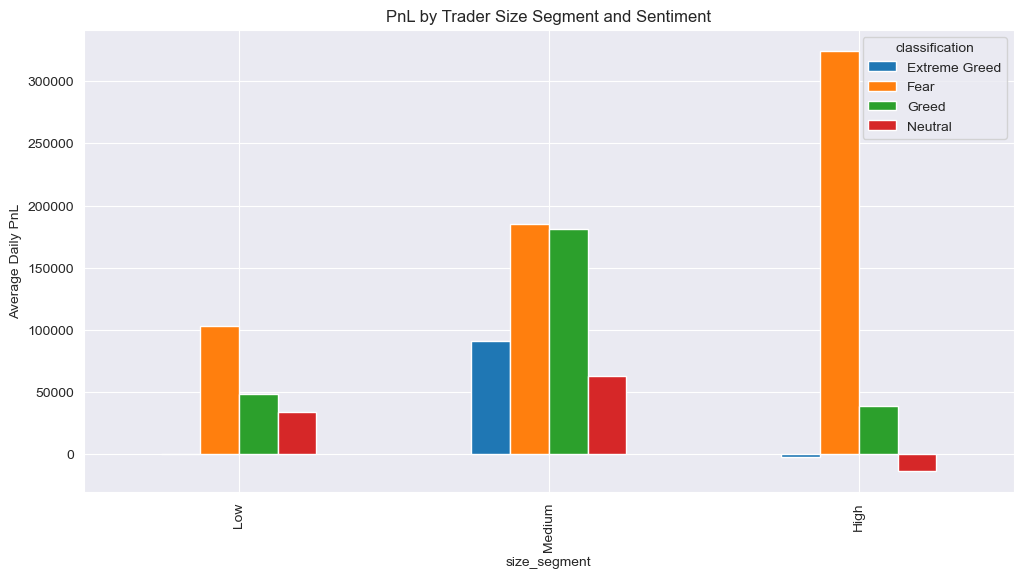

In [10]:
# Define Segments
merged_df['size_segment'] = pd.qcut(merged_df['avg_trade_size'], 3, labels=['Low', 'Medium', 'High'])
merged_df['freq_segment'] = pd.qcut(merged_df['trade_count'], 3, labels=['Low', 'Medium', 'High'])

# Analyze Sensitivity
segment_pnl = merged_df.groupby(['size_segment', 'classification'])['daily_pnl'].mean().unstack()
print(segment_pnl)
segment_pnl.plot(kind='bar', figsize=(12, 6))
plt.title('PnL by Trader Size Segment and Sentiment')
plt.ylabel('Average Daily PnL')
plt.show()

## 7. Predictive Modeling

Model Accuracy: 0.75
              precision    recall  f1-score   support

           0       1.00      0.20      0.33         5
           1       0.73      1.00      0.85        11

    accuracy                           0.75        16
   macro avg       0.87      0.60      0.59        16
weighted avg       0.82      0.75      0.69        16


Feature Importances:
long_ratio        0.292979
trade_count       0.234968
total_volume      0.205240
value             0.150613
avg_trade_size    0.116200
dtype: float64


<Axes: title={'center': 'Feature Importance for Profitability Prediction'}>

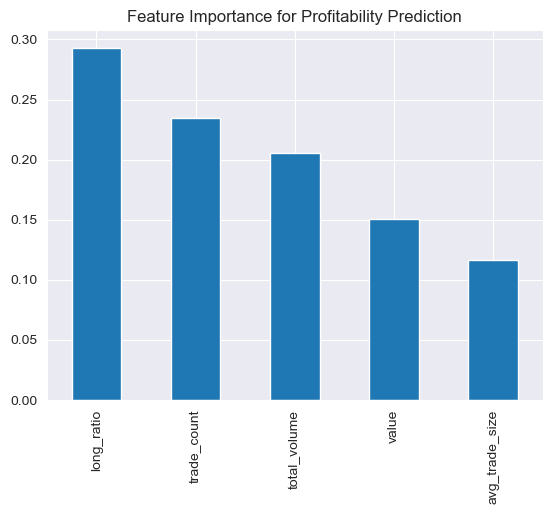

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Target: Profitable Day (1) or Not (0)
merged_df['is_profitable'] = (merged_df['daily_pnl'] > 0).astype(int)

# Features
features = ['value', 'trade_count', 'avg_trade_size', 'long_ratio', 'total_volume']
X = merged_df[features].fillna(0)
y = merged_df['is_profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Feature Importance
importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)
importances.plot(kind='bar', title='Feature Importance for Profitability Prediction')

In [12]:
# Save processed data for Dashboard
merged_df.to_csv('processed_data.csv', index=False)
print("Processed data saved to processed_data.csv")

Processed data saved to processed_data.csv
